<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ...agreuge otras librerías si lo considera relevante

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [3]:
# respuestas

mountain_df = pd.read_csv("Himalayan+Expeditions/peaks_with_exp.csv")
exped_df = pd.read_csv("Himalayan+Expeditions/exped.csv")
members_df = pd.read_csv("Himalayan+Expeditions/members.csv")

mountain_cols = ['peakid', 'pkname', 'heightm', 'success_exp', 'failed_exp']
exped_cols = ['expid', 'year', 'season']
# Agregue las columnas 'peakid' y 'expid' para poder hacer merge a los dfs
members_cols = ['peakid','expid' , 'membid', 'sex', 'yob', 'citizen', 'msuccess']

mountain_df = mountain_df[mountain_cols]
exped_df = exped_df[exped_cols]
members_df = members_df[members_cols]


C:\Users\franc\AppData\Local\Temp\ipykernel_29960\2052478461.py:4: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  exped_df = pd.read_csv("Himalayan+Expeditions/exped.csv")
C:\Users\franc\AppData\Local\Temp\ipykernel_29960\2052478461.py:5: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  members_df = pd.read_csv("Himalayan+Expeditions/members.csv")


In [4]:
df_total = members_df.merge(exped_df, on='expid' , how='left')
df_total = df_total.merge(mountain_df, on='peakid', how='left')

df_total

,peakid,expid,membid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
0,AMAD,AMAD01101,2,M,1972.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
1,AMAD,AMAD01101,1,M,1968.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
2,AMAD,AMAD01101,3,M,1960.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
3,AMAD,AMAD01101,4,M,1966.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
4,AMAD,AMAD01101,5,F,1970.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89084,SURM,SURM74101,2,M,1944.0,UK,False,1974,Spring,Surma-Sarovar North,6564,1,3
89085,SURM,SURM74101,3,M,NaN,UK,False,1974,Spring,Surma-Sarovar North,6564,1,3
89086,SURM,SURM74101,4,M,1948.0,UK,False,1974,Spring,Surma-Sarovar North,6564,1,3
89087,SURM,SURM74101,5,M,NaN,UK,False,1974,Spring,Surma-Sarovar North,6564,1,3


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [5]:
# respuestas

df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   peakid       89089 non-null  object 
 1   expid        89089 non-null  object 
 2   membid       89089 non-null  int64  
 3   sex          89089 non-null  object 
 4   yob          83665 non-null  float64
 5   citizen      89082 non-null  object 
 6   msuccess     89089 non-null  bool   
 7   year         89089 non-null  int64  
 8   season       89089 non-null  object 
 9   pkname       89089 non-null  object 
 10  heightm      89089 non-null  int64  
 11  success_exp  89089 non-null  int64  
 12  failed_exp   89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.2+ MB


Se eliminan las filas que tienen un año de nacimiento mayor al año que se realizo la expedicion dado que no tiene logica, ademas que tambien se van eliminar las filas que no tienen un año de nacimiento, ya que sin ese dato no se va poder calcular la edad del montañista.

In [6]:
df_total = df_total[df_total['yob'] < df_total['year']]
df_total = df_total.dropna(subset='yob')

Se eliminan las filas que no tienen un Pais ya que son solamente 7 y lo cambiamos a categoria, ya que hay 253 valores unicos en esa columna.

In [8]:
df_total['citizen'] = df_total['citizen'].dropna()
#print(len(df_total['citizen'].unique()))
df_total['citizen'] = df_total['citizen'].astype('category')

Se convierte la columna ``sex`` en categoria ya que solo contiene F, M y U. 

In [9]:
df_total['sex'] = df_total['sex'].astype('category')

Se convierte la columna ``msuccess`` en booleanos ya que solo tiene valores de True y False y despues la transformo a int conviertiendo True en 1 y False en 0

In [10]:
df_total['msuccess'] = df_total['msuccess'].astype('bool')
df_total['msuccess'] = df_total['msuccess'].astype('int')

Se convierte la columna ``season`` en categoria ya que contiene 4 valores unicos solamente.

In [11]:
df_total['season'] = df_total['season'].astype('category')

In [12]:
clean_df = df_total.copy()  

In [13]:
df_total[df_total['season'] == 'Summer']

,peakid,expid,membid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
1570,ARNK,ARNK02201,1,M,1942.0,Japan,1,2002,Summer,Arniko Chuli,6034,5,3
1571,ARNK,ARNK02201,3,F,1973.0,Nepal,1,2002,Summer,Arniko Chuli,6034,5,3
1572,ARNK,ARNK02201,2,M,1961.0,Nepal,1,2002,Summer,Arniko Chuli,6034,5,3
2016,GAUG,GAUG02201,1,M,1947.0,Japan,0,2002,Summer,Gaugiri,6110,5,8
2231,SARI,SARI02201,1,M,1942.0,Japan,0,2002,Summer,Saribung,6328,10,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89077,LNPS,LNPS39201,7,M,1913.0,Nepal,0,1939,Summer,Langpo South,6857,2,0
89078,LNPS,LNPS39201,8,M,1916.0,Nepal,0,1939,Summer,Langpo South,6857,2,0
89080,PYRM,PYRM39201,1,M,1893.0,Switzerland,0,1939,Summer,Pyramid Peak,7140,4,6
89081,PYRM,PYRM39201,2,M,1909.0,Germany,0,1939,Summer,Pyramid Peak,7140,4,6


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [14]:
# respuestas

clean_df['age'] = clean_df['year'] - clean_df['yob']

clean_df['peak_success_p'] = clean_df['success_exp'] / (clean_df['success_exp'] + clean_df['failed_exp']) * 100

clean_df.head()

,peakid,expid,membid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp,age,peak_success_p
0,AMAD,AMAD01101,2,M,1972.0,Australia,0,2001,Spring,Ama Dablam,6814,1123,453,29.0,71.256345
1,AMAD,AMAD01101,1,M,1968.0,Australia,0,2001,Spring,Ama Dablam,6814,1123,453,33.0,71.256345
2,AMAD,AMAD01101,3,M,1960.0,Australia,0,2001,Spring,Ama Dablam,6814,1123,453,41.0,71.256345
3,AMAD,AMAD01101,4,M,1966.0,Australia,0,2001,Spring,Ama Dablam,6814,1123,453,35.0,71.256345
4,AMAD,AMAD01101,5,F,1970.0,Australia,0,2001,Spring,Ama Dablam,6814,1123,453,31.0,71.256345


## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

Cantidad  de Ascensos Fallidos: 48365
Porcentaje de Ascensos Fallidos del total: 57.83557548579971%
Cantidad  de Ascensos Exitosos: 35260
Porcentaje de Ascensos Exitosos del total: 42.1644245142003%


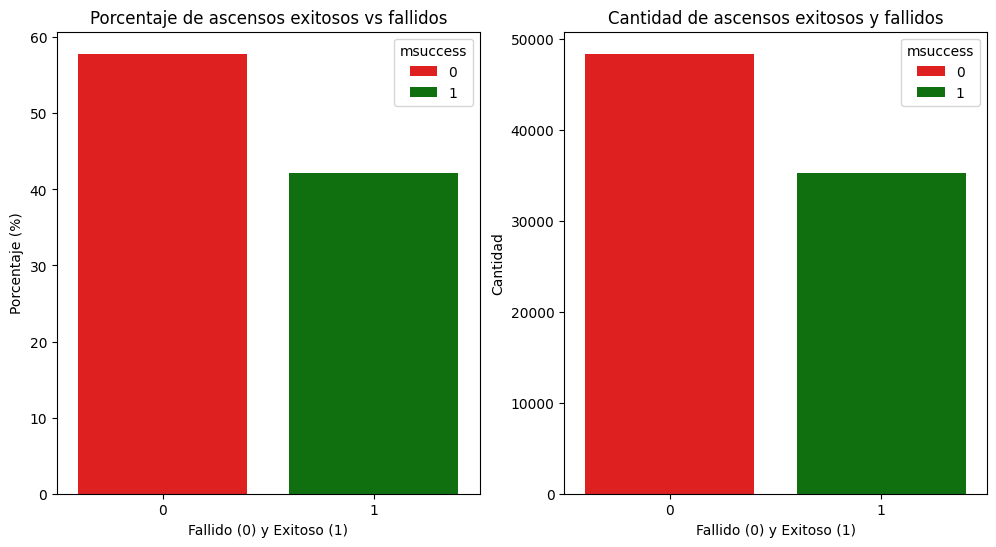

In [17]:
# Respuesta a
counts = clean_df['msuccess'].value_counts()

porc_counts = counts / counts.sum() * 100

print(f"Cantidad  de Ascensos Fallidos: {counts.values[0]}")
print(f"Porcentaje de Ascensos Fallidos del total: {porc_counts.values[0]}%")
print(f"Cantidad  de Ascensos Exitosos: {counts.values[1]}")
print(f"Porcentaje de Ascensos Exitosos del total: {porc_counts.values[1]}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(ax=axes[0], x=counts.index, y=porc_counts.values, hue=counts.index, palette=['red', 'green'])
axes[0].set_title("Porcentaje de ascensos exitosos vs fallidos")
axes[0].set_xlabel("Fallido (0) y Exitoso (1)")
axes[0].set_ylabel("Porcentaje (%)")

sns.countplot(ax=axes[1], data=clean_df, x='msuccess', hue='msuccess', palette=['red', 'green'])
axes[1].set_title("Cantidad de ascensos exitosos y fallidos")
axes[1].set_xlabel("Fallido (0) y Exitoso (1)")
axes[1].set_ylabel("Cantidad")

plt.show()

Respuesta a:

Se puede observar que hay aproximadamente 48.000 ascensos fallidos y aproximadamente 35.000 ascensos exitosos. El porcentaje de ascensos fallidos respecto al total es aproximadamente de 58%, mientras que el porcentajes de ascensos exitosos es de un 42%.

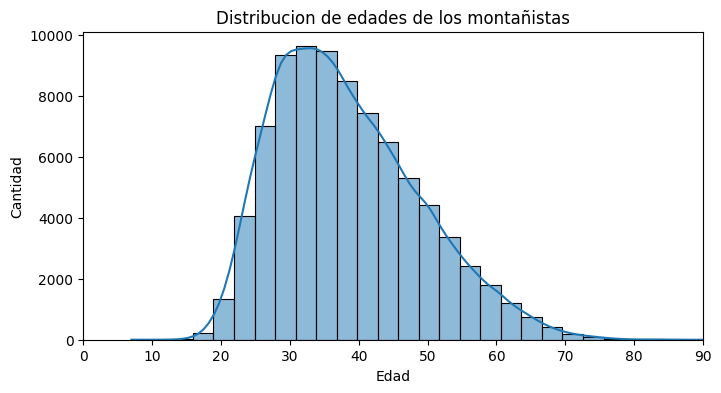

In [18]:
# Respuesta b

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax = sns.histplot(data=clean_df, x='age', bins=50, kde=True)
ax.set_title("Distribucion de edades de los montañistas")
ax.set_xlabel('Edad')
ax.set_ylabel('Cantidad')
ax.set(xlim=(0, 90))

plt.show()

Respuesta b:

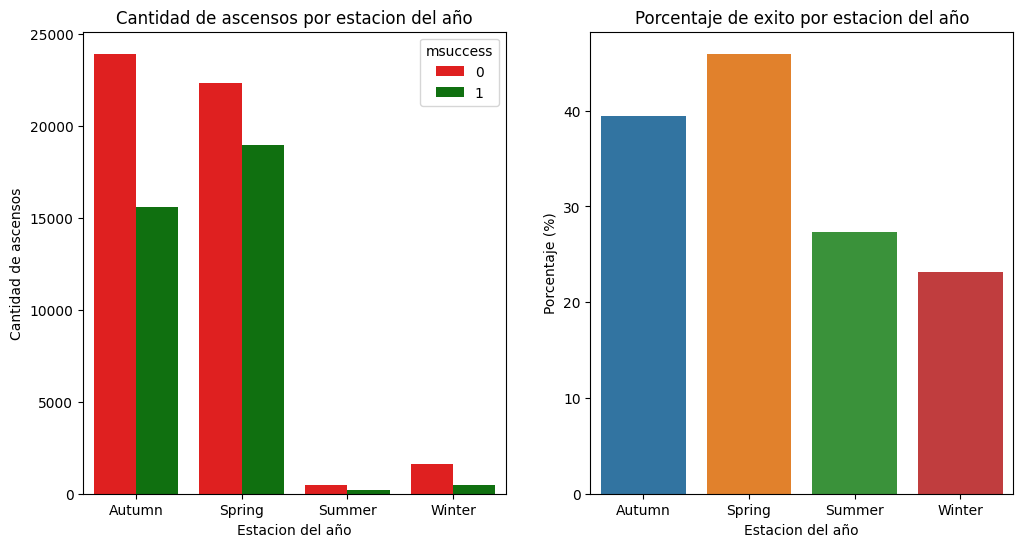

In [19]:
# Respuesta c
porc_exitos = clean_df.groupby('season', observed=False)['msuccess'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(ax=axes[0], data=clean_df, x='season', hue='msuccess', palette=['red', 'green'])
axes[0].set_title("Cantidad de ascensos por estacion del año")
axes[0].set_xlabel("Estacion del año")
axes[0].set_ylabel("Cantidad de ascensos")

sns.barplot(ax=axes[1], x=porc_exitos.index, y=porc_exitos.values, hue=porc_exitos.index)
axes[1].set_title("Porcentaje de exito por estacion del año")
axes[1].set_xlabel("Estacion del año")
axes[1].set_ylabel("Porcentaje (%)")

plt.show()


Respuesta c:



<class 'pandas.core.frame.DataFrame'>
Index: 83625 entries, 0 to 89088
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   peakid          83625 non-null  object  
 1   expid           83625 non-null  object  
 2   membid          83625 non-null  int64   
 3   sex             83625 non-null  category
 4   yob             83625 non-null  float64 
 5   citizen         83625 non-null  category
 6   msuccess        83625 non-null  bool    
 7   year            83625 non-null  int64   
 8   season          83625 non-null  category
 9   pkname          83625 non-null  object  
 10  heightm         83625 non-null  int64   
 11  success_exp     83625 non-null  int64   
 12  failed_exp      83625 non-null  int64   
 13  age             83625 non-null  float64 
 14  peak_success_p  83625 non-null  float64 
dtypes: bool(1), category(3), float64(3), int64(5), object(3)
memory usage: 8.1+ MB


: 

: 

: 

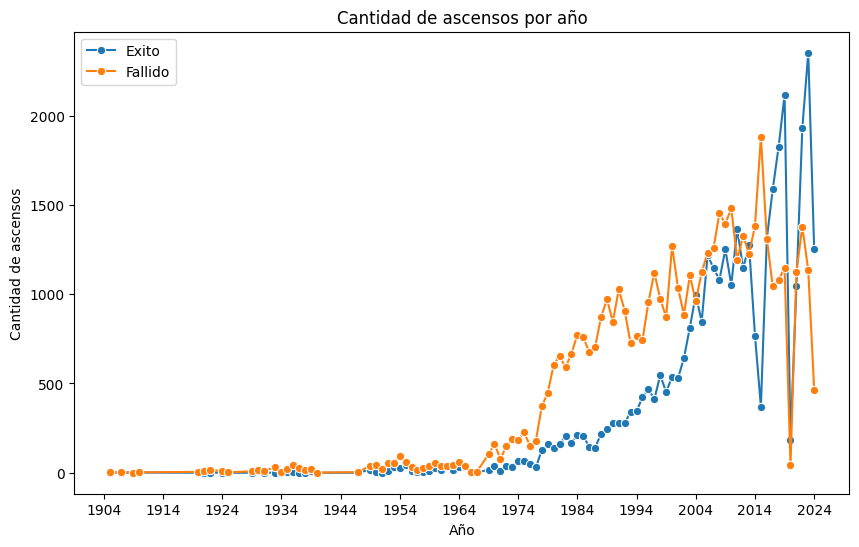

In [21]:
# Respuesta d

year_group = clean_df.groupby('year', observed=False)['msuccess'].value_counts().unstack(fill_value=0)

plt.figure(figsize=(10,6))

sns.lineplot(x=year_group.index, y=year_group[1], label='Exito', marker='o')
sns.lineplot(x=year_group.index, y=year_group[0], label='Fallido', marker='o')

plt.title('Cantidad de ascensos por año')
plt.xlabel("Año")
plt.ylabel("Cantidad de ascensos")
plt.xticks(range(year_group.index.min() - 1, year_group.index.max() + 1, 10))

plt.legend()
plt.show()

Respuesta d:

In [ ]:
# Respuesta e



: 

: 

: 

Respuesta e:



## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [22]:
# respuestas

cols_x = ['age', 'sex', 'citizen', 'season', 'heightm', 'year', 'success_exp', 'failed_exp']
col_y = 'msuccess'

X = clean_df[cols_x].copy()
y = clean_df[col_y].copy()

248

Respuestas: